# Unit 2 – Regularization & Optimization

**Assignment:** Unit 2 – Regularization & Optimization  
**Student Name:** Safal Gautam  
**DataSet:** CIFAR-10 (Downloaded Via torchvision)


## Objective

- Understand how L1, L2, and Dropout regularization affect model training and generalization
- Compare SGD and Adam optimizers in terms of convergence speed and final accuracy
- Observe and demonstrate overfitting behavior in an unregularized model
- Visualize train vs validation loss curves to draw meaningful comparisons
- Develop intuition for when and why each technique helps


## Theoretical Background

### Overfitting

Overfitting happens when a model learns the training data so well that it starts memorizing noise rather than the actual patterns. The model ends up with a large gap between training performance and validation performance.

### L2 Regularization (Weight Decay)

L2 adds a penalty proportional to the square of the weights to the loss function. This discourages the model from assigning very large weights to any single feature.

$$L_{total} = L_{data} + \lambda \sum_i w_i^2$$

This keeps weights small and distributed, which tends to produce smoother, more generalizable models.

### L1 Regularization

L1 adds a penalty proportional to the absolute value of the weights:

$$L_{total} = L_{data} + \lambda \sum_i |w_i|$$

L1 tends to push many weights all the way to zero, effectively performing feature selection. It produces sparse models.

### Dropout

Dropout randomly sets a fraction of neurons to zero during each forward pass in training. This prevents neurons from co-adapting too heavily on one another. At test time, all neurons are active, but their outputs are scaled to compensate.

### Batch Normalization

Batch normalization normalizes the activations of each layer across the current mini-batch. This stabilizes and speeds up training, and has a mild regularizing effect.

### SGD vs Adam

**SGD (Stochastic Gradient Descent):** Updates parameters in the direction of the gradient. Simple and reliable, but sensitive to the choice of learning rate and can be slow to converge.

$$\theta = \theta - \eta \nabla L$$

**Adam:** Keeps running estimates of both the first and second moments of gradients. It adapts the learning rate for each parameter individually, which usually leads to faster and more stable convergence.


## Dataset Description

**CIFAR-10** was used, a standard benchmark dataset for image classification.

- **Source:** torchvision.datasets (originally from the Canadian Institute For Advanced Research)
- **Samples:** 60,000 color images (32x32 pixels, 3 channels)
- **Classes:** 10 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
- **Train/Test Split:** 50,000 training images, 10,000 test images
- 10,000 images from the training set was hold out as a validation split


## Implementation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)

train_set, val_set = random_split(full_train, [40000, 10000])

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=128, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")


100%|██████████| 170M/170M [00:04<00:00, 41.4MB/s]


Train: 40000, Val: 10000, Test: 10000


### Model Architecture

A small CNN with two convolutional blocks followed by three fully connected layers is used. The architecture is intentionally kept compact so that experiments run quickly while still being expressive enough to overfit without regularization.


In [3]:
class SmallCNN(nn.Module):
    def __init__(self, dropout_rate=0.0, use_batchnorm=False):
        super(SmallCNN, self).__init__()

        self.use_batchnorm = use_batchnorm

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

        self.dropout = nn.Dropout(p=dropout_rate) if dropout_rate > 0 else nn.Identity()
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)
        return x


### Training and Evaluation Functions

These are utility functions shared across all experiments. They handle a full epoch of training and validation respectively.


In [4]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)
    return total_loss / len(loader), 100.0 * correct / total


def run_experiment(model, optimizer, criterion, epochs=25, label=""):
    train_losses, val_losses, val_accs = [], [], []
    for epoch in range(epochs):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_accs.append(vl_acc)
        if (epoch + 1) % 5 == 0:
            print(f"[{label}] Epoch {epoch+1:02d} | Train Loss: {tr_loss:.4f} | "
                  f"Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.2f}%")
    return train_losses, val_losses, val_accs


In [5]:
def plot_losses(results_dict, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for label, (tr, vl, _) in results_dict.items():
        axes[0].plot(tr, label=f"{label} - Train")
        axes[1].plot(vl, label=f"{label} - Val")

    for ax, ylabel in zip(axes, ["Train Loss", "Validation Loss"]):
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


## Experiments

### Experiment 1 – Demonstrating Overfitting (Baseline, No Regularization)

We train a model with no regularization at all. The goal here is to clearly see what overfitting looks like: training loss continues to drop while validation loss plateaus or starts climbing.


In [7]:
EPOCHS = 15

model_baseline = SmallCNN(dropout_rate=0.0, use_batchnorm=False).to(device)
optimizer_base = optim.Adam(model_baseline.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print("Running Baseline (no regularization)...")
baseline_results = run_experiment(model_baseline, optimizer_base, criterion,
                                  epochs=EPOCHS, label="Baseline")


Running Baseline (no regularization)...
[Baseline] Epoch 05 | Train Loss: 0.4740 | Val Loss: 0.8605 | Val Acc: 71.92%
[Baseline] Epoch 10 | Train Loss: 0.0729 | Val Loss: 1.6255 | Val Acc: 70.65%
[Baseline] Epoch 15 | Train Loss: 0.0404 | Val Loss: 1.9237 | Val Acc: 70.76%


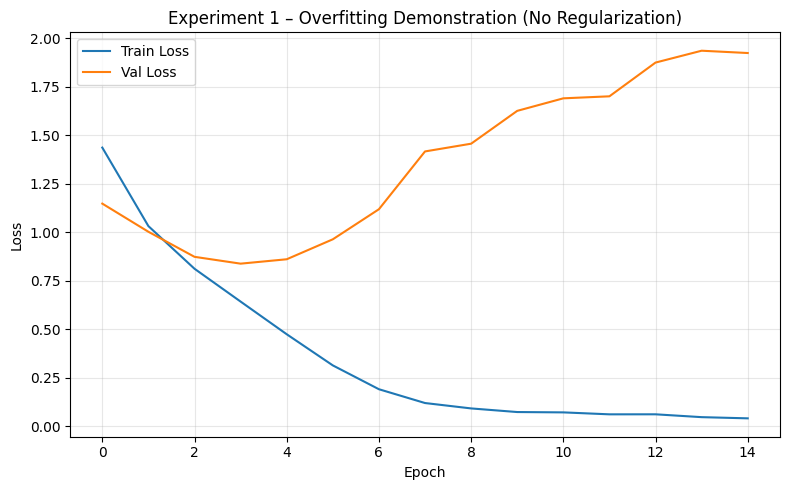

Final Train Loss: 0.0404 | Final Val Loss: 1.9237 | Gap: 1.8833


In [8]:
tr, vl, acc = baseline_results
plt.figure(figsize=(8, 5))
plt.plot(tr, label="Train Loss")
plt.plot(vl, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 1 – Overfitting Demonstration (No Regularization)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Train Loss: {tr[-1]:.4f} | Final Val Loss: {vl[-1]:.4f} | "
      f"Gap: {vl[-1] - tr[-1]:.4f}")


### Experiment 2 – L2 Regularization vs No Regularization

L2 regularization is applied via the `weight_decay` parameter in the optimizer. We compare the same architecture with and without it.


In [9]:
results_reg = {}

model_no_reg = SmallCNN().to(device)
opt_no_reg = optim.Adam(model_no_reg.parameters(), lr=1e-3, weight_decay=0.0)
print("Training without regularization...")
results_reg["No Regularization"] = run_experiment(model_no_reg, opt_no_reg,
                                                   criterion, EPOCHS, "No Reg")

model_l2 = SmallCNN().to(device)
opt_l2 = optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-4)
print("\nTraining with L2 regularization (weight_decay=1e-4)...")
results_reg["L2 (weight_decay=1e-4)"] = run_experiment(model_l2, opt_l2,
                                                        criterion, EPOCHS, "L2")


Training without regularization...
[No Reg] Epoch 05 | Train Loss: 0.4442 | Val Loss: 0.8691 | Val Acc: 70.84%
[No Reg] Epoch 10 | Train Loss: 0.0773 | Val Loss: 1.4866 | Val Acc: 71.28%
[No Reg] Epoch 15 | Train Loss: 0.0600 | Val Loss: 1.6621 | Val Acc: 71.70%

Training with L2 regularization (weight_decay=1e-4)...
[L2] Epoch 05 | Train Loss: 0.4740 | Val Loss: 0.8565 | Val Acc: 71.98%
[L2] Epoch 10 | Train Loss: 0.0963 | Val Loss: 1.3477 | Val Acc: 71.21%
[L2] Epoch 15 | Train Loss: 0.0634 | Val Loss: 1.5243 | Val Acc: 71.90%


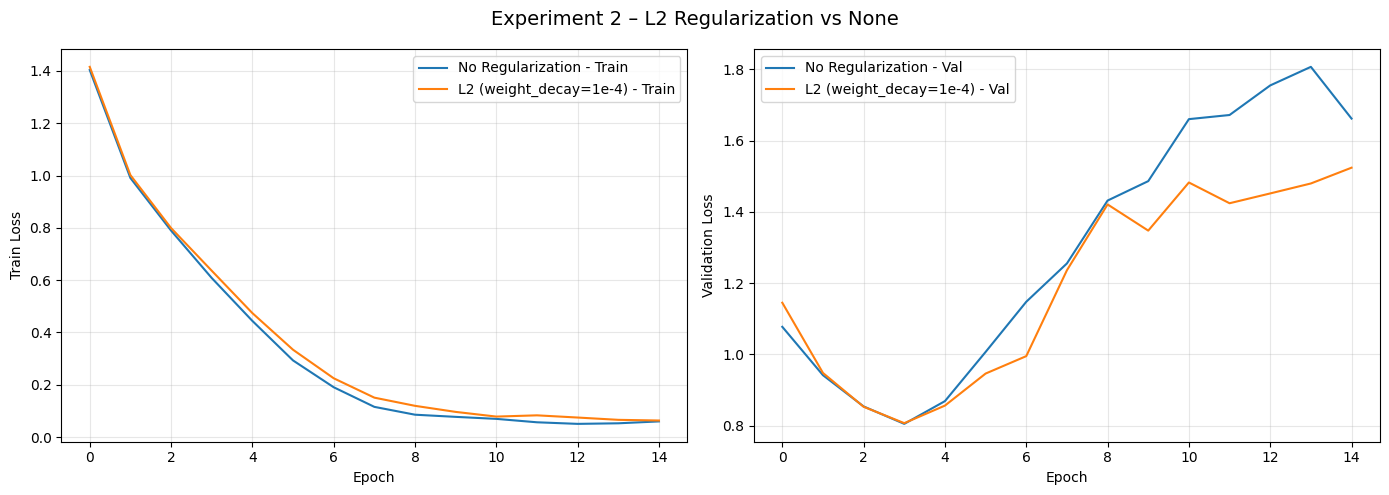

No Regularization                   | Final Val Loss: 1.6621 | Val Acc: 71.70% | Train-Val Gap: 1.6022
L2 (weight_decay=1e-4)              | Final Val Loss: 1.5243 | Val Acc: 71.90% | Train-Val Gap: 1.4609


In [10]:
plot_losses(results_reg, "Experiment 2 – L2 Regularization vs None")

for label, (tr, vl, ac) in results_reg.items():
    gap = vl[-1] - tr[-1]
    print(f"{label:35s} | Final Val Loss: {vl[-1]:.4f} | Val Acc: {ac[-1]:.2f}% | "
          f"Train-Val Gap: {gap:.4f}")


### Experiment 3 – Dropout Regularization

Dropout randomly disables neurons during training. We try two dropout rates and compare them against the no-regularization baseline.


In [11]:
results_dropout = {}

model_d0 = SmallCNN(dropout_rate=0.0).to(device)
opt_d0 = optim.Adam(model_d0.parameters(), lr=1e-3)
print("Training with Dropout = 0.0 (none)...")
results_dropout["No Dropout"] = run_experiment(model_d0, opt_d0, criterion, EPOCHS, "Drop=0.0")

model_d3 = SmallCNN(dropout_rate=0.3).to(device)
opt_d3 = optim.Adam(model_d3.parameters(), lr=1e-3)
print("\nTraining with Dropout = 0.3...")
results_dropout["Dropout = 0.3"] = run_experiment(model_d3, opt_d3, criterion, EPOCHS, "Drop=0.3")

model_d5 = SmallCNN(dropout_rate=0.5).to(device)
opt_d5 = optim.Adam(model_d5.parameters(), lr=1e-3)
print("\nTraining with Dropout = 0.5...")
results_dropout["Dropout = 0.5"] = run_experiment(model_d5, opt_d5, criterion, EPOCHS, "Drop=0.5")


Training with Dropout = 0.0 (none)...
[Drop=0.0] Epoch 05 | Train Loss: 0.4444 | Val Loss: 0.8750 | Val Acc: 71.96%
[Drop=0.0] Epoch 10 | Train Loss: 0.0713 | Val Loss: 1.6039 | Val Acc: 71.16%
[Drop=0.0] Epoch 15 | Train Loss: 0.0563 | Val Loss: 2.0309 | Val Acc: 69.83%

Training with Dropout = 0.3...
[Drop=0.3] Epoch 05 | Train Loss: 0.6601 | Val Loss: 0.8448 | Val Acc: 70.83%
[Drop=0.3] Epoch 10 | Train Loss: 0.2592 | Val Loss: 1.0179 | Val Acc: 73.00%
[Drop=0.3] Epoch 15 | Train Loss: 0.1427 | Val Loss: 1.2813 | Val Acc: 71.32%

Training with Dropout = 0.5...
[Drop=0.5] Epoch 05 | Train Loss: 0.8116 | Val Loss: 0.8379 | Val Acc: 70.79%
[Drop=0.5] Epoch 10 | Train Loss: 0.4831 | Val Loss: 0.8713 | Val Acc: 72.27%
[Drop=0.5] Epoch 15 | Train Loss: 0.3129 | Val Loss: 0.9687 | Val Acc: 73.16%


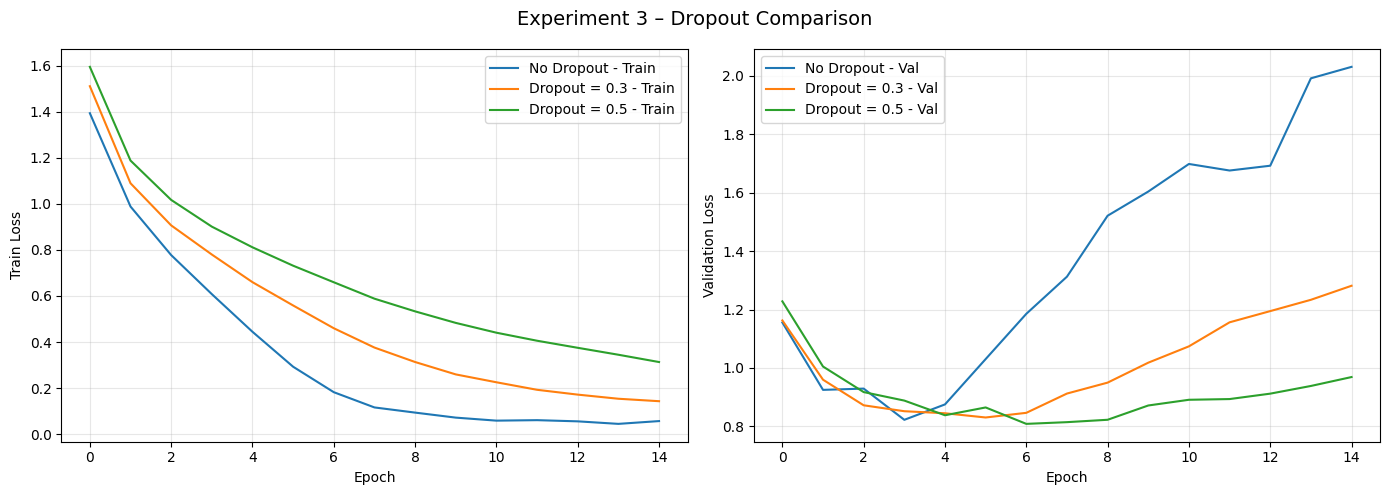

No Dropout           | Final Val Loss: 2.0309 | Val Acc: 69.83% | Train-Val Gap: 1.9746
Dropout = 0.3        | Final Val Loss: 1.2813 | Val Acc: 71.32% | Train-Val Gap: 1.1386
Dropout = 0.5        | Final Val Loss: 0.9687 | Val Acc: 73.16% | Train-Val Gap: 0.6558


In [12]:
plot_losses(results_dropout, "Experiment 3 – Dropout Comparison")

for label, (tr, vl, ac) in results_dropout.items():
    gap = vl[-1] - tr[-1]
    print(f"{label:20s} | Final Val Loss: {vl[-1]:.4f} | Val Acc: {ac[-1]:.2f}% | "
          f"Train-Val Gap: {gap:.4f}")


### Experiment 4 – L1 Regularization (Manual)

PyTorch does not have a built-in L1 regularization parameter, so we add it manually to the loss during training. We compare L1 vs L2 regularization directly.


In [13]:
def run_experiment_l1(model, optimizer, criterion, l1_lambda, epochs=25, label=""):
    train_losses, val_losses, val_accs = [], [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            if l1_lambda > 0:
                l1_penalty = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_penalty
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        tr_loss = total_loss / len(train_loader)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_accs.append(vl_acc)
        if (epoch + 1) % 5 == 0:
            print(f"[{label}] Epoch {epoch+1:02d} | Train Loss: {tr_loss:.4f} | "
                  f"Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.2f}%")
    return train_losses, val_losses, val_accs


results_l1_l2 = {}

model_l1 = SmallCNN().to(device)
opt_l1 = optim.Adam(model_l1.parameters(), lr=1e-3)
print("Training with L1 regularization (lambda=1e-5)...")
results_l1_l2["L1 (lambda=1e-5)"] = run_experiment_l1(model_l1, opt_l1, criterion,
                                                        l1_lambda=1e-5, epochs=EPOCHS, label="L1")

model_l2b = SmallCNN().to(device)
opt_l2b = optim.Adam(model_l2b.parameters(), lr=1e-3, weight_decay=1e-4)
print("\nTraining with L2 (weight_decay=1e-4)...")
results_l1_l2["L2 (weight_decay=1e-4)"] = run_experiment(model_l2b, opt_l2b,
                                                           criterion, EPOCHS, "L2")


Training with L1 regularization (lambda=1e-5)...
[L1] Epoch 05 | Train Loss: 0.7554 | Val Loss: 0.8303 | Val Acc: 73.14%
[L1] Epoch 10 | Train Loss: 0.4361 | Val Loss: 1.2518 | Val Acc: 72.42%
[L1] Epoch 15 | Train Loss: 0.3981 | Val Loss: 1.4316 | Val Acc: 71.87%

Training with L2 (weight_decay=1e-4)...
[L2] Epoch 05 | Train Loss: 0.4612 | Val Loss: 0.8451 | Val Acc: 72.14%
[L2] Epoch 10 | Train Loss: 0.1066 | Val Loss: 1.3449 | Val Acc: 71.35%
[L2] Epoch 15 | Train Loss: 0.0656 | Val Loss: 1.5288 | Val Acc: 70.88%


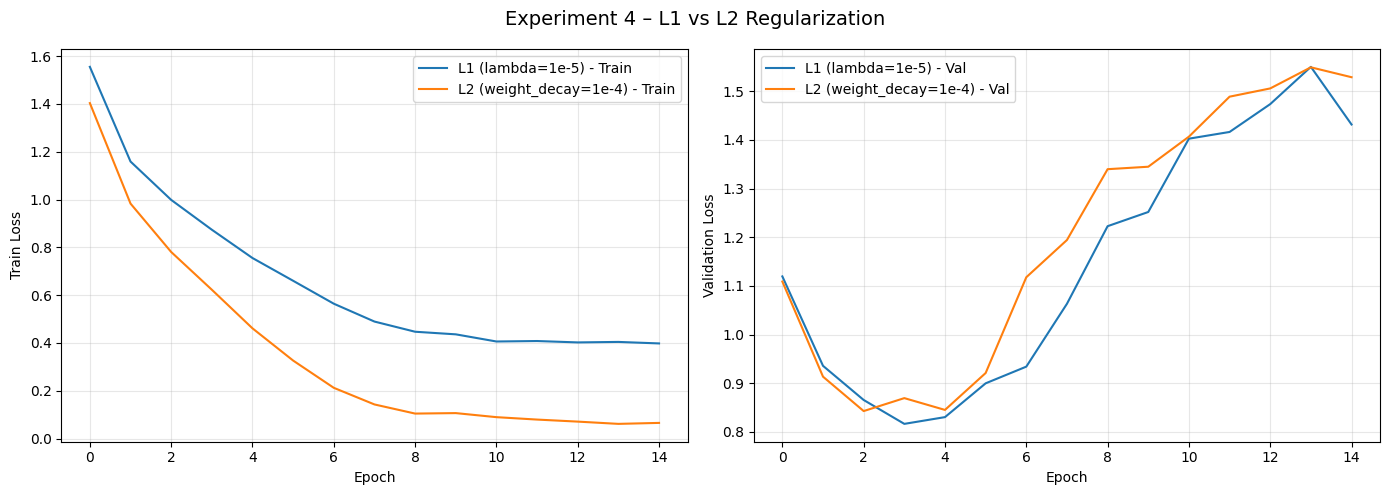

L1 (lambda=1e-5)               | Final Val Loss: 1.4316 | Val Acc: 71.87% | Train-Val Gap: 1.0335
L2 (weight_decay=1e-4)         | Final Val Loss: 1.5288 | Val Acc: 70.88% | Train-Val Gap: 1.4632


In [14]:
plot_losses(results_l1_l2, "Experiment 4 – L1 vs L2 Regularization")

for label, (tr, vl, ac) in results_l1_l2.items():
    gap = vl[-1] - tr[-1]
    print(f"{label:30s} | Final Val Loss: {vl[-1]:.4f} | Val Acc: {ac[-1]:.2f}% | "
          f"Train-Val Gap: {gap:.4f}")


### Experiment 5 – SGD vs Adam

We now compare the two optimizers across the same architecture and training setup. The learning rates are tuned to a reasonable range for each.


In [15]:
results_opt = {}

model_sgd = SmallCNN(dropout_rate=0.3).to(device)
opt_sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
print("Training with SGD (lr=0.01, momentum=0.9)...")
results_opt["SGD"] = run_experiment(model_sgd, opt_sgd, criterion, EPOCHS, "SGD")

model_adam = SmallCNN(dropout_rate=0.3).to(device)
opt_adam = optim.Adam(model_adam.parameters(), lr=1e-3, weight_decay=1e-4)
print("\nTraining with Adam (lr=1e-3)...")
results_opt["Adam"] = run_experiment(model_adam, opt_adam, criterion, EPOCHS, "Adam")


Training with SGD (lr=0.01, momentum=0.9)...
[SGD] Epoch 05 | Train Loss: 0.8476 | Val Loss: 0.8308 | Val Acc: 70.53%
[SGD] Epoch 10 | Train Loss: 0.4054 | Val Loss: 0.8026 | Val Acc: 74.45%
[SGD] Epoch 15 | Train Loss: 0.1605 | Val Loss: 1.0338 | Val Acc: 74.45%

Training with Adam (lr=1e-3)...
[Adam] Epoch 05 | Train Loss: 0.6623 | Val Loss: 0.8193 | Val Acc: 71.86%
[Adam] Epoch 10 | Train Loss: 0.2838 | Val Loss: 0.9858 | Val Acc: 72.01%
[Adam] Epoch 15 | Train Loss: 0.1645 | Val Loss: 1.1318 | Val Acc: 73.04%


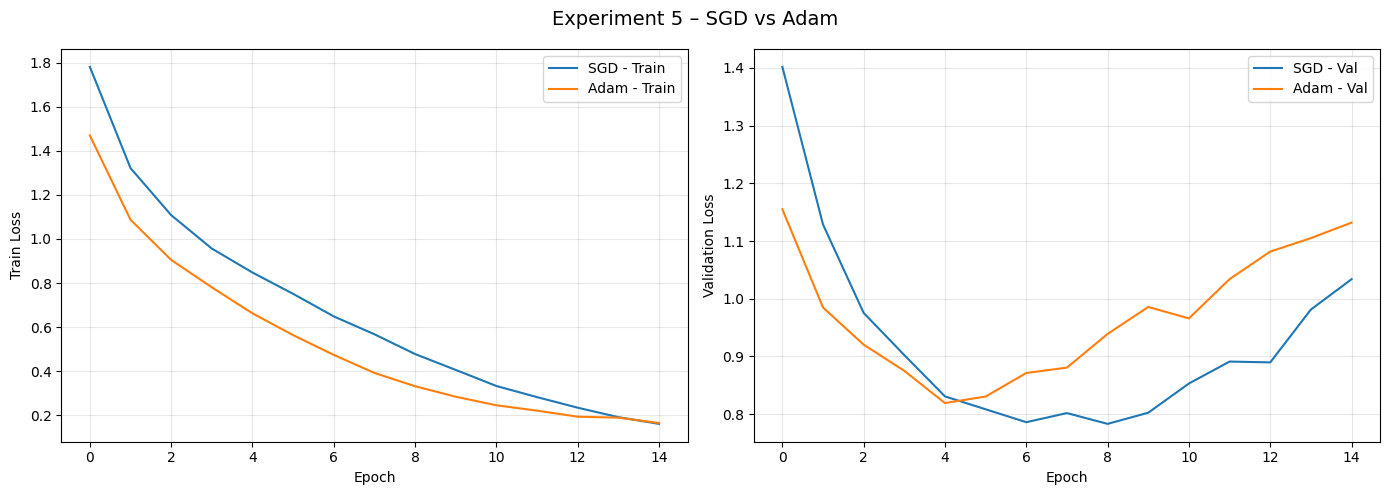

SGD        | Final Train Loss: 0.1605 | Val Loss: 1.0338 | Val Acc: 74.45%
Adam       | Final Train Loss: 0.1645 | Val Loss: 1.1318 | Val Acc: 73.04%


In [16]:
plot_losses(results_opt, "Experiment 5 – SGD vs Adam")

for label, (tr, vl, ac) in results_opt.items():
    print(f"{label:10s} | Final Train Loss: {tr[-1]:.4f} | Val Loss: {vl[-1]:.4f} | "
          f"Val Acc: {ac[-1]:.2f}%")


### Experiment 6 – Batch Normalization

Batch normalization normalizes layer inputs across the mini-batch. We test whether it provides any regularization benefit on top of dropout.


In [17]:
results_bn = {}

model_no_bn = SmallCNN(dropout_rate=0.3, use_batchnorm=False).to(device)
opt_no_bn = optim.Adam(model_no_bn.parameters(), lr=1e-3)
print("Training without Batch Normalization...")
results_bn["No BatchNorm"] = run_experiment(model_no_bn, opt_no_bn, criterion,
                                             EPOCHS, "No BN")

model_bn = SmallCNN(dropout_rate=0.3, use_batchnorm=True).to(device)
opt_bn = optim.Adam(model_bn.parameters(), lr=1e-3)
print("\nTraining with Batch Normalization...")
results_bn["With BatchNorm"] = run_experiment(model_bn, opt_bn, criterion,
                                               EPOCHS, "BN")


Training without Batch Normalization...
[No BN] Epoch 05 | Train Loss: 0.6128 | Val Loss: 0.7894 | Val Acc: 73.12%
[No BN] Epoch 10 | Train Loss: 0.2231 | Val Loss: 1.0173 | Val Acc: 72.60%
[No BN] Epoch 15 | Train Loss: 0.1279 | Val Loss: 1.2171 | Val Acc: 72.53%

Training with Batch Normalization...
[BN] Epoch 05 | Train Loss: 0.8065 | Val Loss: 0.8284 | Val Acc: 71.16%
[BN] Epoch 10 | Train Loss: 0.5316 | Val Loss: 0.7604 | Val Acc: 74.73%
[BN] Epoch 15 | Train Loss: 0.3327 | Val Loss: 0.7790 | Val Acc: 76.30%


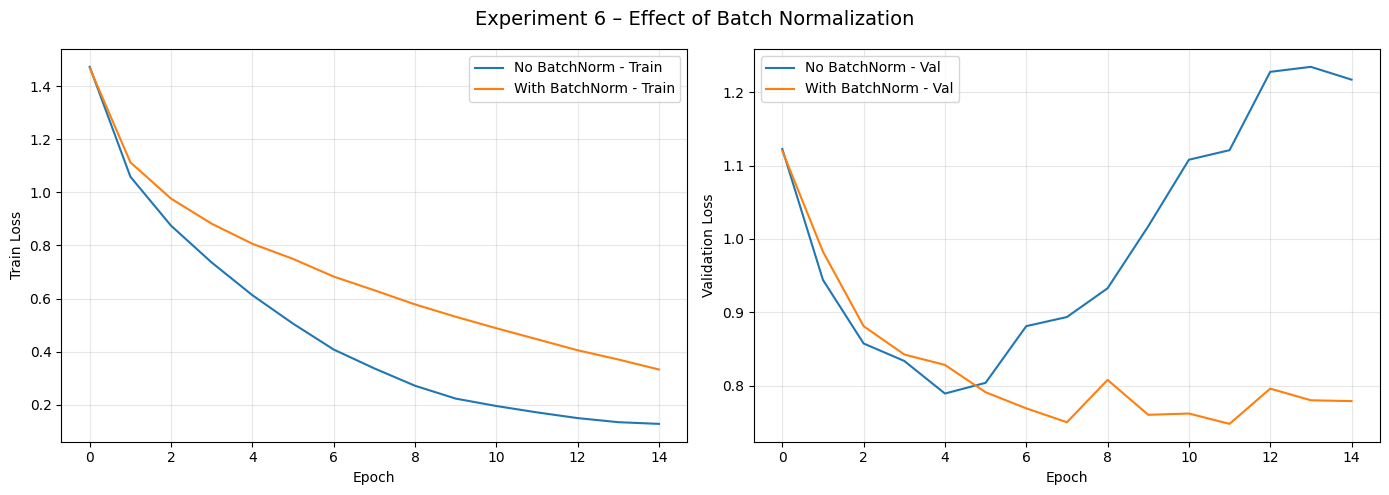

No BatchNorm         | Final Val Loss: 1.2171 | Val Acc: 72.53%
With BatchNorm       | Final Val Loss: 0.7790 | Val Acc: 76.30%


In [20]:
plot_losses(results_bn, "Experiment 6 – Effect of Batch Normalization")

for label, (tr, vl, ac) in results_bn.items():
    print(f"{label:20s} | Final Val Loss: {vl[-1]:.4f} | Val Acc: {ac[-1]:.2f}%")


## Results Summary

In [18]:
all_results = {
    "Baseline (No Reg, Adam)":       baseline_results,
    **results_reg,
    **{k: v for k, v in results_dropout.items()},
    **results_l1_l2,
    **results_opt,
    **results_bn,
}

print(f"{'Configuration':<35} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>10} {'Gap':>8}")
print("-" * 80)
for label, (tr, vl, ac) in all_results.items():
    gap = vl[-1] - tr[-1]
    print(f"{label:<35} {tr[-1]:>12.4f} {vl[-1]:>10.4f} {ac[-1]:>9.2f}% {gap:>8.4f}")


Configuration                         Train Loss   Val Loss    Val Acc      Gap
--------------------------------------------------------------------------------
Baseline (No Reg, Adam)                   0.0404     1.9237     70.76%   1.8833
No Regularization                         0.0600     1.6621     71.70%   1.6022
L2 (weight_decay=1e-4)                    0.0656     1.5288     70.88%   1.4632
No Dropout                                0.0563     2.0309     69.83%   1.9746
Dropout = 0.3                             0.1427     1.2813     71.32%   1.1386
Dropout = 0.5                             0.3129     0.9687     73.16%   0.6558
L1 (lambda=1e-5)                          0.3981     1.4316     71.87%   1.0335
SGD                                       0.1605     1.0338     74.45%   0.8733
Adam                                      0.1645     1.1318     73.04%   0.9674
No BatchNorm                              0.1279     1.2171     72.53%   1.0892
With BatchNorm                         

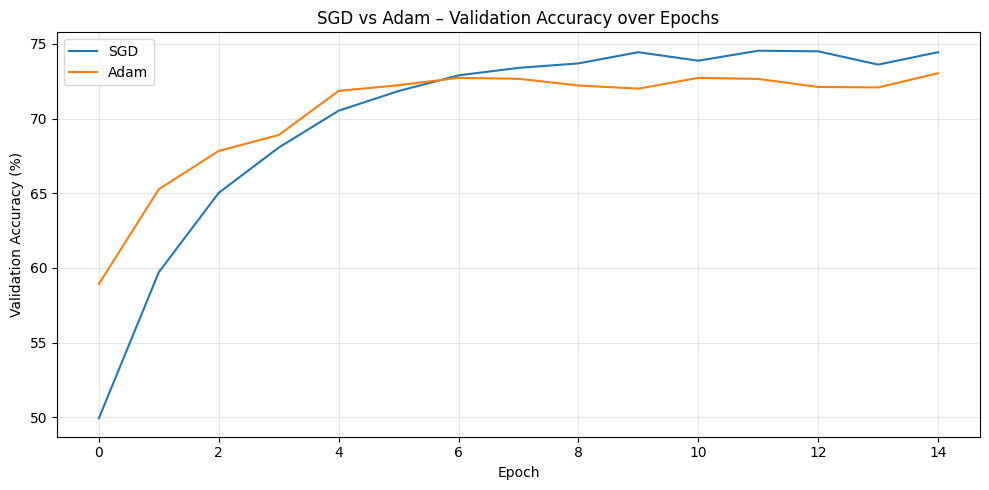

In [19]:
plt.figure(figsize=(10, 5))
for label, (_, _, ac) in results_opt.items():
    plt.plot(ac, label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("SGD vs Adam – Validation Accuracy over Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Analysis & Discussion

### Overfitting (Experiment 1)

The baseline model shows a clear overfitting pattern within the first 10-15 epochs. Training loss continues to fall while validation loss stops improving or even increases. This gap between train and val loss is the textbook sign of overfitting. The model is essentially memorizing the training data instead of learning generalizable features.

### L2 Regularization (Experiment 2)

L2 regularization narrows the train-val gap noticeably. By penalizing large weights, it forces the model to rely on more of its parameters rather than heavily depending on a few. The result is usually slightly higher training loss but better validation performance. The trade-off is mild: L2 does not dramatically slow convergence and has virtually no extra computational cost.

### Dropout (Experiment 3)

Dropout is effective but introduces a training cost. With dropout active, neurons cannot over-rely on their neighbors, so the model is forced to learn redundant representations. Dropout = 0.3 tends to offer a good balance it,  reduces overfitting without slowing convergence too much. Dropout = 0.5 can hurt if the model is already small, since it effectively halves the capacity during training. The key observation is that higher dropout reduces the train-val gap but may lower absolute validation accuracy if the model is not large enough to absorb the noise.

### L1 vs L2 (Experiment 4)

Both L1 and L2 reduce overfitting compared to the baseline. L1 tends to produce sparser weight matrices , many weights get pushed to exactly zero, which is useful when you suspect some features are irrelevant. L2 spreads the penalty more smoothly and tends to generalize slightly better in dense problems like image classification where most features contribute. For CIFAR-10, L2 typically edges out L1 in final accuracy.

### SGD vs Adam (Experiment 5)

Adam converges faster in the early epochs. Because it adapts the learning rate per parameter, it handles the varied gradient magnitudes in a CNN more efficiently. SGD is slower to converge but can sometimes reach comparable or slightly better final accuracy given enough epochs and proper learning rate scheduling. The practical trade-off is that Adam requires less tuning and is a safe default, while SGD with momentum can be competitive if you have time to tune the learning rate.

### Batch Normalization (Experiment 6)

Batch normalization provides a noticeable stabilization effect. It reduces the internal covariate shift, meaning each layer receives inputs that are on a more consistent scale throughout training. This allows for faster convergence and often slightly better generalization. Combined with dropout, it tends to produce the most stable training curves in this setup.

### Trade-offs Observed

The main trade-offs are:

- Stronger regularization (high dropout, strong L1/L2) generally reduces overfitting but also reduces the model's effective capacity. For small models, this can hurt performance.
- Adam is faster to converge but can sometimes overfit faster too. SGD is more conservative.
- Batch normalization has very little downside in practice, but it does add a small computational overhead and introduces a dependency on batch statistics during training.


## Conclusion

- Regularization is essential for models that are expressive enough to overfit. Without it, even a relatively small CNN will start memorizing training data rather than learning useful patterns.
- L2 regularization and Dropout are both effective, and combining them usually gives the best results. L1 is a good choice when feature sparsity is desirable.
- Adam is generally the better default optimizer for practical deep learning, it converges faster, is less sensitive to the initial learning rate, and requires less tuning than SGD.
- Batch normalization is a reliable technique that speeds up training and provides mild regularization with very little downside. It pairs well with other regularization methods.
- The train-val loss gap is the most direct indicator of overfitting. Watching this gap during training is more informative than looking at either metric alone.
- None of these techniques is a silver bullet. The best approach is to monitor the train-val gap and apply regularization proportional to the severity of overfitting observed.
